## PROJECT
# Industrial Steel Defect Classification Using Transfer Learning

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d kaustubhdikshit/neu-surface-defect-database

Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
100% 26.4M/26.4M [00:00<00:00, 138MB/s] 



In [ ]:
import zipfile
zip_ref=zipfile.ZipFile("/content/neu-surface-defect-database.zip","r")
zip_ref.extractall("/content")
zip_ref.close()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras import Sequential

In [ ]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    "/content/NEU-DET/train/images",
    batch_size=32,
    image_size=(224,224),
    label_mode="categorical",
    shuffle=True


)

val_ds=tf.keras.utils.image_dataset_from_directory(
    "/content/NEU-DET/validation/images",
    batch_size=32,
    image_size=(224,224),
    label_mode="categorical",
    shuffle=True


)

Found 1440 files belonging to 6 classes.
Found 360 files belonging to 6 classes.


In [ ]:
import os
classes=['crazing',
 'inclusion',
 'patches',
 'pitted_surface',
 'rolled-in_scale',
 'scratches']
for i in classes:
  count=len(os.listdir(f"/content/NEU-DET/train/images/{i}"))
  print(count)

240
240
240
240
240
240


In [ ]:
aug=Sequential([
    RandomZoom(0.2),
    RandomFlip("horizontal"),
    RandomRotation(0.2)
])


In [ ]:
from tensorflow.keras.utils import save_img
os.makedirs("augmented_dataset",exist_ok=True)

for i in train_ds.class_names:
  os.makedirs(os.path.join("augmented_dataset",i),exist_ok=True)
count=0
for image,labels in train_ds:

  for ver in range(5):
    class_index = np.argmax(labels[ver].numpy())
    class_name = train_ds.class_names[class_index]
    augmented_images=aug(image,
    training=True)

    for img in range(image.shape[0]):
      class_index = np.argmax(labels[img].numpy())
      class_name = train_ds.class_names[class_index]

      save_img(  os.path.join(
                "augmented_dataset",
                class_name,
                f"aug_{count}_v{ver}.jpg") ,
                augmented_images[img]
                )
      count+=1





In [ ]:
import os
classes=['crazing',
 'inclusion',
 'patches',
 'pitted_surface',
 'rolled-in_scale',
 'scratches']
for i in classes:
  count=len(os.listdir(f"/content/augmented_dataset/{i}"))
  print(count)

1200
1200
1200
1200
1200
1200


In [ ]:
train_ds1=tf.keras.utils.image_dataset_from_directory(
    "/content/augmented_dataset",
    batch_size=32,
    image_size=(224,224),
    label_mode="categorical",
    shuffle=True


)

val_ds11=tf.keras.utils.image_dataset_from_directory(
    "/content/NEU-DET/validation/images",
    batch_size=32,
    image_size=(224,224),
    label_mode="categorical",
    shuffle=False


)
train_class_names = train_ds1.class_names
val_class_names = val_ds11.class_names

print("Train:", train_class_names)
print("Validation:", val_class_names)

Found 7200 files belonging to 6 classes.
Found 360 files belonging to 6 classes.
Train: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Validation: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [ ]:
for images, labels in train_ds1.take(1):
  print(images.shape)
  print(labels.shape)

(32, 224, 224, 3)
(32, 6)


In [ ]:
from tensorflow.keras.applications.vgg19 import preprocess_input

def process(image, label):
    image = preprocess_input(image)
    return image, label

train_ds=train_ds1.map(process)
val_ds=val_ds11.map(process)

In [ ]:
from tensorflow.keras.applications.vgg19 import VGG19
conv_base=VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras import Model,Input,layers
input=Input(shape=(224,224,3))
x=conv_base(input,training=False)
x=layers.GlobalAveragePooling2D()(x)
x=layers.Dense(32,activation="relu")(x)
x=layers.Dropout(0.2)(x)
x=layers.BatchNormalization()(x)
output=Dense(6,activation="softmax")(x)
model=Model(inputs=input,
            outputs=output)




In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,041,126 (76.45 MB)

 Trainable params: 20,041,062 (76.45 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
model.compile(tf.keras.optimizers.Adam(0.001),loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
history=model.fit(train_ds,validation_data=val_ds,epochs=10)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 213s 740ms/step - accuracy: 0.3249 - loss: 1.5291 - val_accuracy: 0.1667 - val_loss: 1.9698
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 152s 673ms/step - accuracy: 0.3878 - loss: 1.3492 - val_accuracy: 0.2417 - val_loss: 1.5408
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 672ms/step - accuracy: 0.4658 - loss: 1.2012 - val_accuracy: 0.3306 - val_loss: 2.5691
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 152s 674ms/step - accuracy: 0.5260 - loss: 1.0285 - val_accuracy: 0.3694 - val_loss: 1.8453
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 670ms/step - accuracy: 0.5242 - loss: 1.0211 - val_accuracy: 0.3667 - val_loss: 1.9263
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 671ms/step - accuracy: 0.4644 - loss: 1.0924 - val_accuracy: 0.2306 - val_loss: 1.6557
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 152s 673ms/step - accuracy: 0.4963 - loss: 1.0317 - val_accuracy: 0.4139 - val_loss: 1.6044
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 671ms/step - accuracy: 0.5204 -

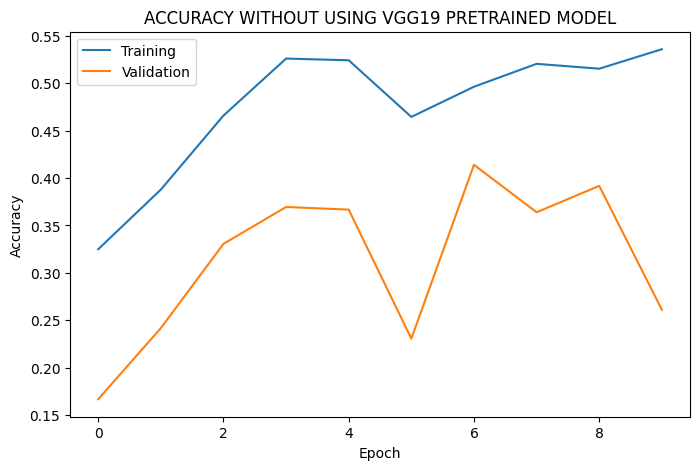

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("ACCURACY WITHOUT USING VGG19 PRETRAINED MODEL")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

In [ ]:
conv_base.trainable = True

set_trainable = False

for layer in conv_base.layers:

    if layer.name == "block5_conv1":
        set_trainable = True

    layer.trainable = set_trainable

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 73s 302ms/step - accuracy: 0.5263 - loss: 0.9131 - val_accuracy: 0.5333 - val_loss: 0.9251
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 67s 295ms/step - accuracy: 0.5233 - loss: 0.9321 - val_accuracy: 0.6806 - val_loss: 0.8975
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 67s 295ms/step - accuracy: 0.5376 - loss: 0.9086 - val_accuracy: 0.6583 - val_loss: 0.9134
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 66s 294ms/step - accuracy: 0.5439 - loss: 0.9037 - val_accuracy: 0.6722 - val_loss: 0.9110
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 67s 296ms/step - accuracy: 0.5412 - loss: 0.9180 - val_accuracy: 0.6361 - val_loss: 0.9190
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 67s 296ms/step - accuracy: 0.5521 - loss: 0.8984 - val_accuracy: 0.6444 - val_loss: 0.9200
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 67s 296ms/step - accuracy: 0.5496 - loss: 0.9070 - val_accuracy: 0.6472 - val_loss: 0.9214
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 67s 296ms/step - accuracy: 0.5511 - loss: 0

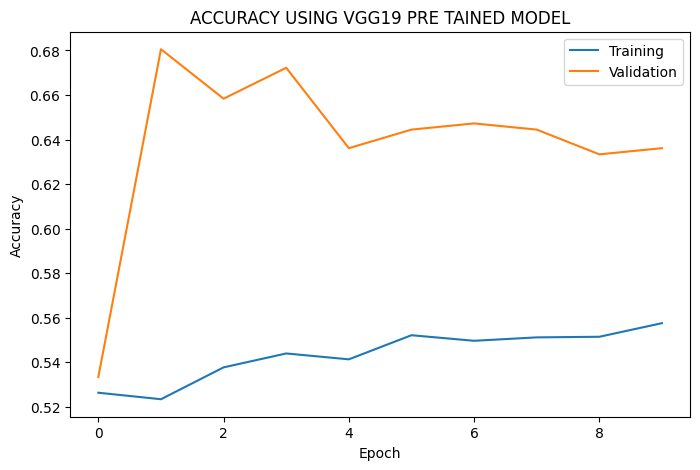

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history_fine.history["accuracy"])
plt.plot(history_fine.history["val_accuracy"])
plt.title("ACCURACY USING VGG19 PRE TAINED MODEL")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

In [ ]:
img=load_img("/content/augmented_dataset/patches/aug_1003_v1.jpg")

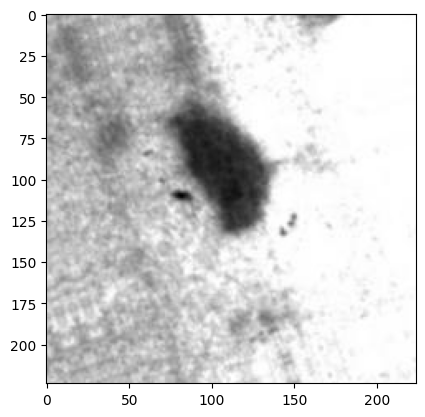

In [ ]:
plt.imshow(img
           )

In [ ]:
img_arr=img_to_array(img)
img=tf.expand_dims(img_arr,axis=0)

In [ ]:
prediction=model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
class_names = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

predicted_class = np.argmax(prediction[0])

print("Predicted:", class_names[predicted_class])
print("Confidence:", prediction[0][predicted_class])

Predicted: patches
Confidence: 0.54106563
